# PyPSA tutorial: Refugee Camp

## What is PyPSA?

**PyPSA (Python for Power System Analysis)** is an open-source Python library designed for modeling and optimizing modern power systems. It provides a flexible framework for simulating electricity networks, conducting power flow analysis, performing energy system optimization, market dispatch and multi-sector coupling.

## Key Features

- **Economic Dispatch**: Short-term market dispatch with unit commitment, renewables, storage and multi-carrier conversion.
- **Static Power Flow Analysis**: Build power systems using buses, lines, transformers, generators, loads, and storage etc and perform AC and DC power flow calculations.
- **Time series optimization**: Optimize dispatch and capacity expansion over multiple time periods 
- **Optimal Power Flow (LOPF and SCLOPF)**: Optimize power flow in AC-DC networks using linearized KVL/KCL constraints with optional loss approximations, and accounting for line outage contingencies under N-1 conditions.
- **Flexibile and Multi-Sector**: Model everything from single buildings to continental-scale energy systems, including sector coupling e.g. (electricity, heat, hydrogen etc.)
- **Open source**: Free to use, modify, and extend

## Core Concepts

### 1. Network Object
The `pypsa.Network()` is the central container that holds all components of your power system and optimization results.

### 2. Snapshots
The time index for your simulation - defines when and how often the system is evaluated (e.g., hourly for a year).

### 3. Components
- **Buses**: Nodes where components connect (like electrical junction points)
- **Generators**: Power production (solar, wind, gas, nuclear, etc.)
- **Loads**: Power consumption (buildings, industry, etc.)
- **Links**: Connections that transfer power between buses (can model conversion efficiencies)
- **Lines**: Specific links relating to electrical transmission
- **StorageUnits**: Energy storage devices (batteries, pumped hydro)
- **Stores**: Energy reservoirs (can represent exports, imports, or long-term storage)

### 4. Carriers
Energy types or technologies (electricity, solar, wind, gas) that allow tracking of attributes like CO₂ emissions across the network.

### 5. Optimization Types
- **Dispatch optimization**: Given fixed capacities, determine optimal operation over time
- **Capacity expansion**: Determine optimal capacities to install (in addition to optimal operation)

In [1]:
# start by importing pypsa
import pypsa
import pandas as pd

In [3]:
# create empty network
n = pypsa.Network()

In [4]:
# create 7 buses at 120V AC
# See https://docs.pypsa.org/latest/user-guide/components/buses/
for i in range(7):
    n.add("Bus", f"Bus {i+1}", v_nom=120/1000, carrier="AC")

In [5]:
# add lines between the buses
# See https://docs.pypsa.org/latest/user-guide/components/lines/
for i in range(6):
    n.add("Line", f"Line {i+1}-{i+2}", bus0=f"Bus {i+1}", bus1=f"Bus {i+2}", x=0.37, r=0.37, length=0.05)

In [6]:
# add generator at bus 1 as a slack 
# See https://docs.pypsa.org/latest/user-guide/components/generators/
n.add("Generator", "Generator 1", bus="Bus 1", control="Slack")

Index(['Generator 1'], dtype='object')

In [7]:
# add loads of 300 W at each bus except bus 1
# See https://docs.pypsa.org/latest/user-guide/components/loads/
pf = 0.95
s = 300 / 1000**2  # convert W to MW
p = s * pf
q = s * (1 - pf**2)**0.5
for i in range(1, 7):
    n.add("Load", f"Load {i+1}", bus=f"Bus {i+1}", p_set=p, q_set=q)

In [8]:
# we can summarise the network by printing it
n

Unnamed PyPSA Network
---------------------
Components:
 - Bus: 7
 - Generator: 1
 - Line: 6
 - Load: 6
Snapshots: 1

In [9]:
# Perform the power flow calculations
n.pf()

INFO:pypsa.pf:Performing non-linear load-flow on AC sub-network <pypsa.networks.SubNetwork object at 0x16df0cd70> for snapshots Index(['now'], dtype='object', name='snapshot')


{'n_iter': SubNetwork  0
 snapshot     
 now         3,
 'error': SubNetwork             0
 snapshot                
 now         1.823273e-07,
 'converged': SubNetwork     0
 snapshot        
 now         True}

In [11]:
# check the bus voltages as before
print(n.buses_t['v_mag_pu'])

Bus       Bus 1     Bus 2     Bus 3     Bus 4    Bus 5     Bus 6     Bus 7
snapshot                                                                  
now         1.0  0.924194  0.859836  0.807559  0.76789  0.741228  0.727833


In [107]:
n.lines

,bus0,bus1,type,x,r,g,b,s_nom,s_nom_mod,s_nom_extendable,...,v_ang_max,sub_network,x_pu,r_pu,g_pu,b_pu,x_pu_eff,r_pu_eff,s_nom_opt,v_nom
Line,,,,,,,,,,,,,,,,,,,,,
Line 1-2,Bus 1,Bus 2,,0.37,0.37,0.0,0.0,0.0,0.0,False,...,inf,0,25.694444,25.694444,0.0,0.0,25.694444,25.694444,0.0,0.12
Line 2-3,Bus 2,Bus 3,,0.37,0.37,0.0,0.0,0.0,0.0,False,...,inf,0,25.694444,25.694444,0.0,0.0,25.694444,25.694444,0.0,0.12
Line 3-4,Bus 3,Bus 4,,0.37,0.37,0.0,0.0,0.0,0.0,False,...,inf,0,25.694444,25.694444,0.0,0.0,25.694444,25.694444,0.0,0.12
Line 4-5,Bus 4,Bus 5,,0.37,0.37,0.0,0.0,0.0,0.0,False,...,inf,0,25.694444,25.694444,0.0,0.0,25.694444,25.694444,0.0,0.12
Line 5-6,Bus 5,Bus 6,,0.37,0.37,0.0,0.0,0.0,0.0,False,...,inf,0,25.694444,25.694444,0.0,0.0,25.694444,25.694444,0.0,0.12
Line 6-7,Bus 6,Bus 7,,0.37,0.37,0.0,0.0,0.0,0.0,False,...,inf,0,25.694444,25.694444,0.0,0.0,25.694444,25.694444,0.0,0.12


## Optimization
PyPSA can do a lot more than just power flow calculations. It can also optimize the operation and investment of energy systems over multiple time steps. This is done by formulating a linear programming problem that minimizes the total cost of the system while satisfying various constraints. The core theory of optimization is beyond the scope of this course. PyPSA provides documentation https://docs.pypsa.org/latest/user-guide/optimization/overview/.

Below we will set up a simple optimisation for the refugee camp that optimises the sizing and operation of a solar PV system and battery storage. 

We usually want to minimise the total cost of the system over a period of time. To do this, we will need temporal profiles for both the load and the renewable generation. 



In [13]:
# import PV data
bidibidi_pv = pd.read_csv("../Data/Generation/ninja_pv_3.5006_31.4071.csv", skiprows=3, index_col=0, parse_dates=True)[["electricity"]]

# import example load data
load_profiles = pd.read_csv("../Data/Demand/bidibidi_load_profiles.csv", index_col=0, parse_dates=True)

<Axes: xlabel='time'>

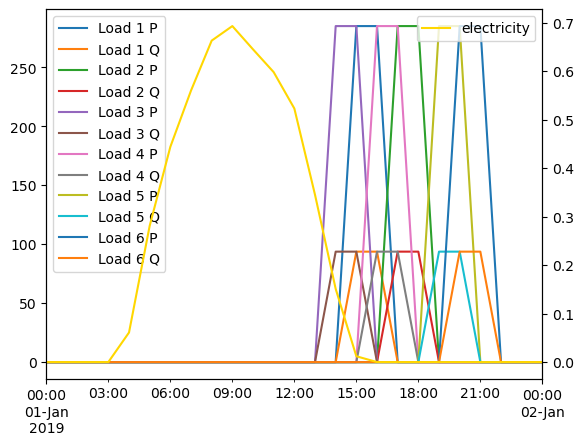

In [19]:
ax = load_profiles.loc[pd.Timestamp('2019-01-01'):pd.Timestamp('2019-01-02')].plot()
ax2 = ax.twinx()
bidibidi_pv.loc[pd.Timestamp('2019-01-01'):pd.Timestamp('2019-01-02')].plot(ax=ax2, color='gold')

In [31]:
# create a new network
net = pypsa.Network()

In [32]:
# we now need to tell PyPSA that we want to do a time series simulation, in PyPSA this is done by setting the snapshot attribute of the network
net.set_snapshots(load_profiles.index)

In [33]:
# add a carrier for AC
net.add(
    "Carrier",
    "AC",
)

Index(['AC'], dtype='object')

In [34]:
# create the buses as before
for i in range(7):
    net.add("Bus", f"Bus {i+1}", v_nom=120/1000, x=i, y=0,)

# add the lines as before
for i in range(6):
    net.add("Line", f"Line {i+1}-{i+2}", bus0=f"Bus {i+1}", bus1=f"Bus {i+2}",
            x=0.37, r=0.37, s_nom_extendable=True, overwrite=True)


In [35]:
# add loads - now we set the p to be the time series power profiles
for i in range(1, 7):
    net.add("Load", f"Load {i}", bus=f"Bus {i+1}", 
           p_set=load_profiles[f"Load {i} P"].values/1000**2,
           overwrite=True)

In [36]:
# now we add a generator that is expandable. 
# We need to provide a pu time series output (e.g. a capacity factor) and a capital cost for the optimisation cost function to minimise.
net.add("Generator", "Solar", bus="Bus 1", 
       p_max_pu=bidibidi_pv["electricity"].values,
       p_nom_extendable=True,
       capital_cost=600000, # capital cost in $/MW
       lifetime=25 # for annuitized investment costs
       ) 

Index(['Solar'], dtype='object')

In [37]:
# add extendable battery storage at bus 1, defined by power capacity and max hours at rated power.
# note, you require a link and store combination to optimise both power and energy independently.
net.add("StorageUnit", "Battery", bus="Bus 1",
       p_nom_extendable=True,
       capital_cost=600000,  # capital cost in $/MW
       lifetime=15,
       max_hours=4,  # hours of storage at nominal power
       cyclic_state_of_charge=True,
       initial_state_of_charge=(6*300*2*2)/1000**2, # 2 days * 6 * 300 * 2hrs 
       overwrite=True, 
       )

Index(['Battery'], dtype='object')

In [38]:
# run the dispatch and capacity expansion optimisation
net.optimize()

INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 8/8 [00:00<00:00, 85.12it/s]
INFO:linopy.io: Writing time: 0.8s


Running HiGHS 1.11.0 (git hash: n/a): Copyright (c) 2025 HiGHS under MIT licence terms
LP   linopy-problem-kvqhoccr has 245288 rows; 87608 cols; 477415 nonzeros
Coefficient ranges:
  Matrix [1e-03, 4e+00]
  Cost   [6e+05, 6e+05]
  Bound  [0e+00, 0e+00]
  RHS    [3e-04, 3e-04]
Presolving model
48167 rows, 30649 cols, 118221 nonzeros  0s
26945 rows, 13820 cols, 63341 nonzeros  0s
21309 rows, 8184 cols, 50566 nonzeros  0s
15654 rows, 6922 cols, 44174 nonzeros  0s
Dependent equations search running on 1836 equations with time limit of 1000.00s
Dependent equations search removed 0 rows and 0 nonzeros in 0.00s (limit = 1000.00s)
15654 rows, 6922 cols, 44174 nonzeros  0s
Presolve : Reductions: rows 15654(-229634); columns 6922(-80686); elements 44174(-433241)
Solving the presolved LP
Using EKK dual simplex solver - serial
  Iteration        Objective     Infeasibilities num(sum)
          0     3.4201839816e+02 Pr: 1471(1.32596) 0s
       7426     1.5886727880e+03 Pr: 0(0) 0s
Solving the orig

INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 87608 primals, 245288 duals
Objective: 1.59e+03
Solver model: available
Solver message: Optimal



Writing the solution to /private/var/folders/c1/br5rnxrj6qn9cx7wcd7pm9040000gr/T/linopy-solve-5qngn9fk.sol


INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-ext-p-lower, Generator-ext-p-upper, Line-ext-s-lower, Line-ext-s-upper, StorageUnit-ext-p_dispatch-lower, StorageUnit-ext-p_dispatch-upper, StorageUnit-ext-p_store-lower, StorageUnit-ext-p_store-upper, StorageUnit-ext-state_of_charge-lower, StorageUnit-ext-state_of_charge-upper, StorageUnit-energy_balance were not assigned to the network.


('ok', 'optimal')

In [39]:
print(f"Optimal PV capacity: {net.generators.p_nom_opt.sum()*1000:.2f} kW")
print(f"Optimal Battery capacity: {net.storage_units.p_nom_opt.sum()*1000:.2f} kW")
print(f"Optimal Battery energy capacity: {net.storage_units.p_nom_opt.sum()*1000*net.storage_units.max_hours.sum():.2f} kWh")

Optimal PV capacity: 1.43 kW
Optimal Battery capacity: 1.22 kW
Optimal Battery energy capacity: 4.88 kWh


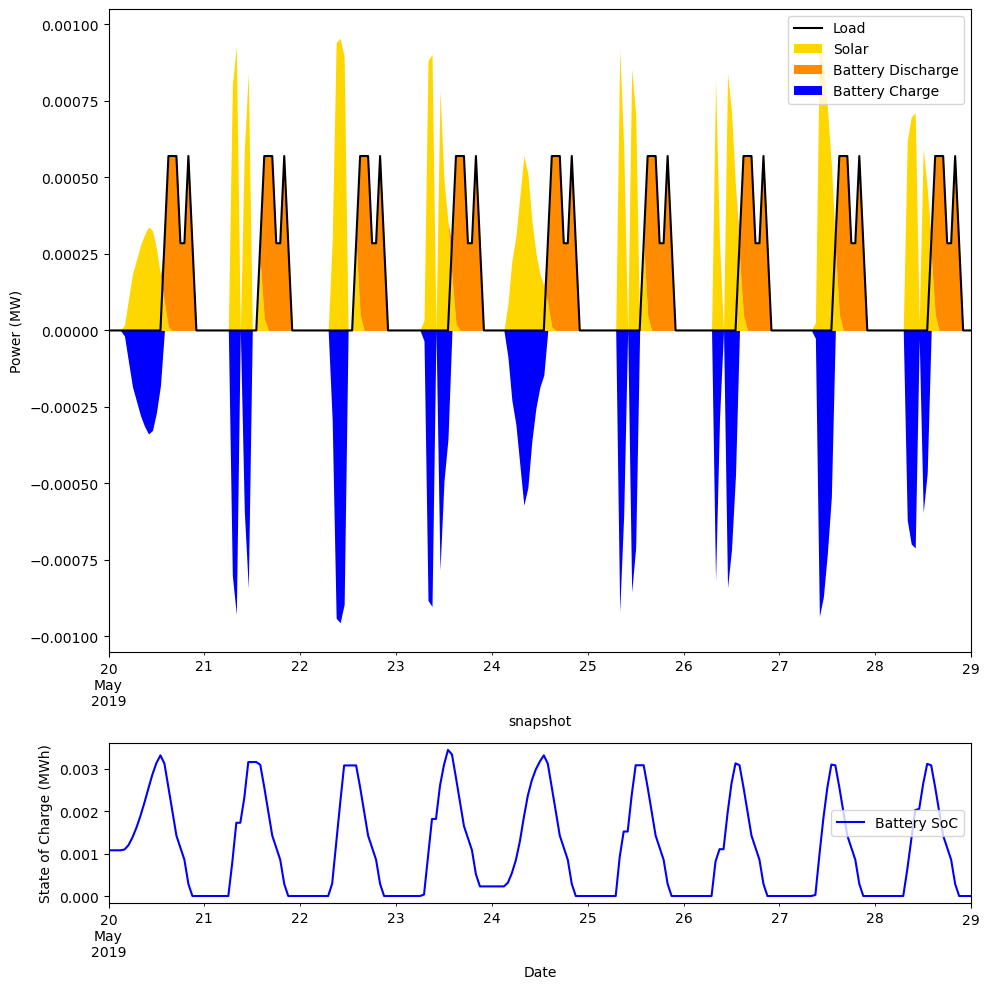

In [40]:
import matplotlib.pyplot as plt

fig_start = pd.Timestamp(2019, 5, 20)
fig_end   = pd.Timestamp(2019, 5, 29)

fig, (ax, ax2) = plt.subplots(nrows=2, figsize=(10, 10), gridspec_kw={"height_ratios": [4, 1]})

# 1) Load line on ax
load_series = net.loads_t.p.sum(axis=1).loc[fig_start:fig_end]
load_series.plot(ax=ax, label="Load", color="black")

# 2) Generation + storage as stacked area on the same ax
stack = pd.concat([
    net.generators_t.p.loc[fig_start:fig_end, "Solar"],
    net.storage_units_t.p_dispatch.loc[fig_start:fig_end, "Battery"],
    -net.storage_units_t.p_store.loc[fig_start:fig_end, "Battery"],
], axis=1)

stack.columns = ["Solar", "Battery Discharge", "Battery Charge"]  # labels for legend
stack.plot.area(
    ax=ax, stacked=True, linewidth=0.0,
    color=["gold", "darkorange", "blue"]
)

ax.set_ylabel("Power (MW)")
ax.legend(loc="upper right")

# 3) State of charge on ax2
soc = net.storage_units_t.state_of_charge.loc[fig_start:fig_end, "Battery"]
soc.plot(ax=ax2, color="blue", label="Battery SoC")
ax2.set_ylabel("State of Charge (MWh)")
ax2.set_xlabel("Date")
ax2.legend()

plt.tight_layout()
plt.show()

The power flow calculation is independent of the optimisation. A common workflow is to first optimise the network with the linearised approximations of n.optimize() and then to run the non-linear power flow calculation on the optimised network with n.pf() for validation, using the power imbalances from the optimisation as setpoints. There is a function that does this for you, n.optimize.optimize_and_run_non_linear_powerflow().

In [41]:
net.optimize.optimize_and_run_non_linear_powerflow()

INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 8/8 [00:00<00:00, 87.00it/s]
INFO:linopy.io: Writing time: 0.83s


Running HiGHS 1.11.0 (git hash: n/a): Copyright (c) 2025 HiGHS under MIT licence terms
LP   linopy-problem-4p1263wq has 245288 rows; 87608 cols; 477415 nonzeros
Coefficient ranges:
  Matrix [1e-03, 4e+00]
  Cost   [6e+05, 6e+05]
  Bound  [0e+00, 0e+00]
  RHS    [3e-04, 3e-04]
Presolving model
48167 rows, 30649 cols, 118221 nonzeros  0s
26945 rows, 13820 cols, 63341 nonzeros  0s
21309 rows, 8184 cols, 50566 nonzeros  0s
15654 rows, 6922 cols, 44174 nonzeros  0s
Dependent equations search running on 1836 equations with time limit of 1000.00s
Dependent equations search removed 0 rows and 0 nonzeros in 0.00s (limit = 1000.00s)
15654 rows, 6922 cols, 44174 nonzeros  0s
Presolve : Reductions: rows 15654(-229634); columns 6922(-80686); elements 44174(-433241)
Solving the presolved LP
Using EKK dual simplex solver - serial
  Iteration        Objective     Infeasibilities num(sum)
          0     3.4201839816e+02 Pr: 1471(1.32596) 0s
       7426     1.5886727880e+03 Pr: 0(0) 0s
Solving the orig

INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 87608 primals, 245288 duals
Objective: 1.59e+03
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-ext-p-lower, Generator-ext-p-upper, Line-ext-s-lower, Line-ext-s-upper, StorageUnit-ext-p_dispatch-lower, StorageUnit-ext-p_dispatch-upper, StorageUnit-ext-p_store-lower, StorageUnit-ext-p_store-upper, StorageUnit-ext-state_of_charge-lower, StorageUnit-ext-state_of_charge-upper, StorageUnit-energy_balance were not assigned to the network.
INFO:pypsa.optimization.abstract:Running non-linear power flow iteratively...
INFO:pypsa.pf:Performing non-linear load-flow on AC sub-network <pypsa.networks.SubNetwork object at 0x1781d6930> for snapshots DatetimeIndex(['2019-01-01 00:00:00', '2019-01-01 01:00:00',
               '2019-01-01 02:00:00', '2019-01-01 03:00:00',
               '2019-01-01 04:00:00', '2019-01-01 05:

{'status': 'ok',
 'terminantion_condition': 'optimal',
 'n_iter': SubNetwork           0
 snapshot              
 2019-01-01 00:00:00  0
 2019-01-01 01:00:00  0
 2019-01-01 02:00:00  0
 2019-01-01 03:00:00  0
 2019-01-01 04:00:00  0
 ...                 ..
 2019-12-31 19:00:00  2
 2019-12-31 20:00:00  2
 2019-12-31 21:00:00  2
 2019-12-31 22:00:00  0
 2019-12-31 23:00:00  0
 
 [8760 rows x 1 columns],
 'error': SubNetwork                      0
 snapshot                         
 2019-01-01 00:00:00  0.000000e+00
 2019-01-01 01:00:00  0.000000e+00
 2019-01-01 02:00:00  0.000000e+00
 2019-01-01 03:00:00  0.000000e+00
 2019-01-01 04:00:00  0.000000e+00
 ...                           ...
 2019-12-31 19:00:00  5.687352e-08
 2019-12-31 20:00:00  7.198849e-07
 2019-12-31 21:00:00  1.029146e-07
 2019-12-31 22:00:00  0.000000e+00
 2019-12-31 23:00:00  0.000000e+00
 
 [8760 rows x 1 columns],
 'converged': SubNetwork              0
 snapshot                 
 2019-01-01 00:00:00  True
 2019-01-

Text(0, 0.5, 'Voltage (p.u.)')

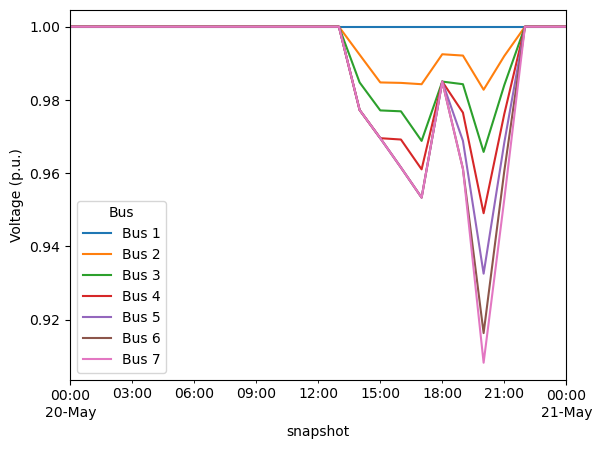

In [42]:
ax = net.buses_t['v_mag_pu'].loc[pd.Timestamp(2019, 5, 20):pd.Timestamp(2019, 5, 21), :].plot()
ax.set_ylabel("Voltage (p.u.)")

## Activity
Try adding an additional generation component to represent a grid connection to the microgrid. Assign it a marginal cost that is competitive with your solar and battery system. Add a carrier to track the CO2 emissions from grid electricity. Rerun the optimisation and see how the system changes.

In [136]:
# create a dataframe for hourly load profiles for 6 houses for 1 year. Each house should have a p and a q profile, assuming a power factor of 0.95. Add some temporal diversity between houses. Each house should peak at 300 W at some point during the day.and

import pandas as pd
import numpy as np 
hours = pd.date_range("2019-01-01", "2019-12-31 23:00", freq="h")
load_profiles = pd.DataFrame(index=hours)
pf = 0.95
for i in range(6):
    peak_hour = np.random.randint(15, 23)  # peak between 12 noon and 8 PM accounting for time zone
    profile = np.zeros((24, 365))
    profile[peak_hour-1:peak_hour+1, :] = 300  # peak at 300 W for 2 hours
    p_profile = profile.T.flatten() * pf
    q_profile = profile.T.flatten() * (1 - pf**2)**0.5
    load_profiles[f"Load {i+1} P"] = p_profile
    load_profiles[f"Load {i+1} Q"] = q_profile


In [137]:
load_profiles.to_csv("../Data/Demand/bidibidi_load_profiles.csv")